In [113]:
# Import libraries
import yfinance as yf
import numpy as np
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import seaborn as sns
import torch.optim as optim

**DATA GENERATION**

In [114]:
tickers = ["AAPL","MSFT","NVDA","AMD","GOOG", "META", "AMZN", "TSLA", "INTC", "IBM"]
data = yf.download(tickers, start="2018-01-01")['Close']
data = data.dropna() # drop rows with missing values
# print(data.head())

# Training / Test split
x_test = yf.download(tickers, start="2023-01-01")['Close'] # test on future data
y_test = x_test.pct_change().dropna() # predict next-day returns

x_train = data[data.index < "2023-01-01"] # train on past data
y_train = x_train.pct_change().dropna()

# Test prints
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("Training returns shape:", y_train.shape)
print("Test returns shape:", y_test.shape)

print("Training data head:")
print(x_train.head())
print("Training returns head:")
print(y_train.head())

[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed

Training data shape: (1259, 10)
Test data shape: (808, 10)
Training returns shape: (1258, 10)
Test returns shape: (807, 10)
Training data head:
Ticker           AAPL    AMD       AMZN       GOOG         IBM       INTC  \
Date                                                                        
2018-01-02  40.304176  10.98  59.450500  52.816380  103.412842  39.330383   
2018-01-03  40.297157  11.55  60.209999  53.683258  106.255417  37.995590   
2018-01-04  40.484344  12.12  60.479500  53.877666  108.407494  37.298809   
2018-01-05  40.945267  11.88  61.457001  54.662720  108.937126  37.559055   
2018-01-08  40.793179  12.28  62.343498  54.896301  109.594154  37.559055   

Ticker            META       MSFT      NVDA       TSLA  
Date                                                    
2018-01-02  180.007401  78.870354  4.928267  21.368668  
2018-01-03  183.232086  79.237411  5.252614  21.150000  
2018-01-04  182.894730  79.934822  5.280303  20.974667  
2018-01-05  185.395126  80.9258

In [115]:
x_test_tensor = torch.tensor(x_test.values[:-1], dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

x_train_tensor = torch.tensor(x_train.values[:-1], dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

# Test prints
print("Aligned training data shape:", x_train_tensor.shape)
print("Aligned test data shape:", x_test_tensor.shape)
print("Aligned training returns shape:", y_train_tensor.shape)
print("Aligned test returns shape:", y_test_tensor.shape)

print("Aligned training data head:")
print(x_train_tensor[:5])
print("Aligned training returns head:")
print(y_train_tensor[:5])

Aligned training data shape: torch.Size([1258, 10])
Aligned test data shape: torch.Size([807, 10])
Aligned training returns shape: torch.Size([1258, 10])
Aligned test returns shape: torch.Size([807, 10])
Aligned training data head:
tensor([[ 40.3042,  10.9800,  59.4505,  52.8164, 103.4128,  39.3304, 180.0074,
          78.8704,   4.9283,  21.3687],
        [ 40.2972,  11.5500,  60.2100,  53.6833, 106.2554,  37.9956, 183.2321,
          79.2374,   5.2526,  21.1500],
        [ 40.4843,  12.1200,  60.4795,  53.8777, 108.4075,  37.2988, 182.8947,
          79.9348,   5.2803,  20.9747],
        [ 40.9453,  11.8800,  61.4570,  54.6627, 108.9371,  37.5591, 185.3951,
          80.9259,   5.3250,  21.1053],
        [ 40.7932,  12.2800,  62.3435,  54.8963, 109.5942,  37.5591, 186.8140,
          81.0084,   5.4882,  22.4273]])
Aligned training returns head:
tensor([[-0.0002,  0.0519,  0.0128,  0.0164,  0.0275, -0.0339,  0.0179,  0.0047,
          0.0658, -0.0102],
        [ 0.0046,  0.0494,  0.00

**GRAPH CONSTRUCTION**

In [116]:
def stock_graph(y):
    # correlation matrix as adjacency (as a start)
    corr = np.corrcoef(y.T)
    np.fill_diagonal(corr, 0)  # remove self-loops
    return corr

def normalize_graph(G):
    # optional: divide by largest eigenvalue
    eigs = np.linalg.eigvals(G)
    return G / np.max(np.abs(eigs))

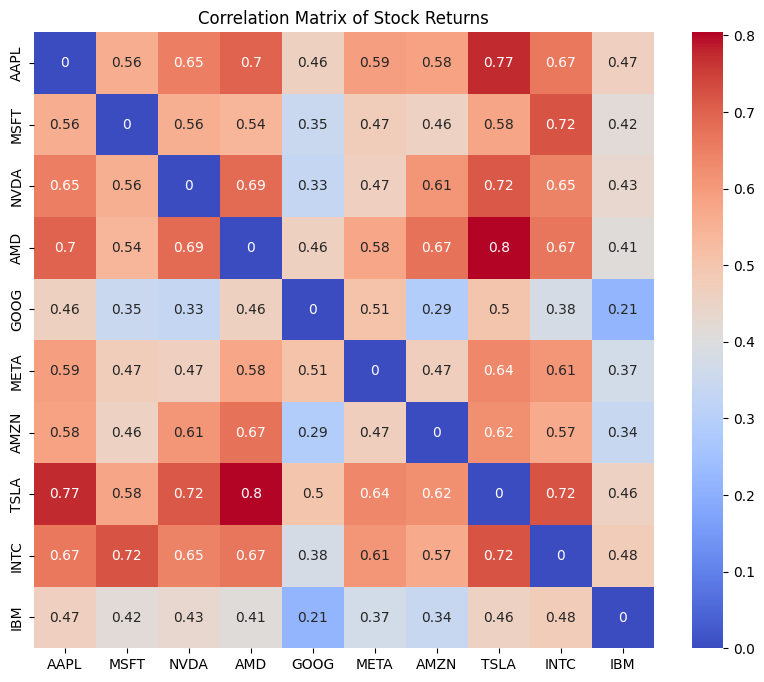

In [117]:
# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(stock_graph(y_train), annot=True, cmap='coolwarm', xticklabels=tickers, yticklabels=tickers)
plt.title('Correlation Matrix of Stock Returns')
plt.show()

**GRAPH FILTER**

In [118]:
def filter_function(h, S, x):
    """
    Preforms graph filtering on the input signal x using the filter coefficients h and the graph Laplacian S.

    ARGS:
    h: filter coefficients (h_1, h_2, ..., h_K)
    S: graph Laplacian
    x: input signal size (B,N)

    RETURNS:
    y: output signal after applying the graph filter
    """

    K = h.shape[0] # number of filter coefficients h_1, h_2, ..., h_K
    B = x.shape[0] # batch size (number of samples processed in parallel)
    N = x.shape[1] # number of nodes (= number of stocks in our case)

    x = x.reshape([B, 1, N]) 
    S = S.reshape([1, N, N])
    z = x

    for k in range(1, K):

        # diffusion step, S^k*x
        x = torch.matmul(x, S)
        xS = x.reshape([B, 1, N]) 

        # concatenate the S^k*x in the tensor z
        z = torch.cat((z, xS), dim=1) 

    # multiply z and h in the concatenation dimension
    y = torch.matmul(z.permute(0, 2, 1).reshape([B, N, K]), h)

    return y

class graph_filter(nn.Module):
    """
    Graph filter layer that applies a learnable graph filter to the input signal.
    """
    def __init__(self, corr, k):
        
        # Initialize parent
        super().__init__()
        
        # Save filter hyperparameters
        self.graph = torch.tensor(corr)
        self.n = corr.shape[0]
        self.k = k
        
        # Define and initialize learnable weights
        self.weight = nn.Parameter(torch.randn(self.k))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        return filter_function(self.weight, self.graph, x)

**TEST GRAPH FILTER LAYER**

In [119]:
def train_model(model, x_train, y_train, lr=0.01, epochs=300):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = criterion(y_pred, y_train)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
        if loss.item() < 1e-6:
            print(f"Early stopping at epoch {epoch+1} with loss {loss.item():.6f}")
            break
    return model, losses

In [121]:
class graph_perceptron(nn.Module):
    def __init__(self, gso, k, sigma):
        super().__init__()
        self.gso = torch.tensor(gso)
        self.n = gso.shape[0]
        self.k = k
        self.sigma = sigma
        self.weight = nn.Parameter(torch.randn(self.k))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        y = filter_function(self.weight, self.gso, x)
        y = self.sigma(y)
        return y    

Training Graph Filter...
Epoch 10/300, Loss: 1732.291748
Epoch 20/300, Loss: 694.513062
Epoch 30/300, Loss: 634.578003
Epoch 40/300, Loss: 499.129639
Epoch 50/300, Loss: 349.949554
Epoch 60/300, Loss: 265.282562
Epoch 70/300, Loss: 190.924301
Epoch 80/300, Loss: 133.535309
Epoch 90/300, Loss: 91.754707
Epoch 100/300, Loss: 60.987873
Epoch 110/300, Loss: 39.644245
Epoch 120/300, Loss: 25.107426
Epoch 130/300, Loss: 15.577512
Epoch 140/300, Loss: 9.510991
Epoch 150/300, Loss: 5.775441
Epoch 160/300, Loss: 3.547674
Epoch 170/300, Loss: 2.262455
Epoch 180/300, Loss: 1.545375
Epoch 190/300, Loss: 1.158811
Epoch 200/300, Loss: 0.957561
Epoch 210/300, Loss: 0.856416
Epoch 220/300, Loss: 0.807275
Epoch 230/300, Loss: 0.784078
Epoch 240/300, Loss: 0.773273
Epoch 250/300, Loss: 0.768118
Epoch 260/300, Loss: 0.765407
Epoch 270/300, Loss: 0.763687
Epoch 280/300, Loss: 0.762338
Epoch 290/300, Loss: 0.761109
Epoch 300/300, Loss: 0.759904


/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_26674/281005117.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.graph = torch.tensor(corr)
/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_26674/3123335899.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.gso = torch.tensor(gso)


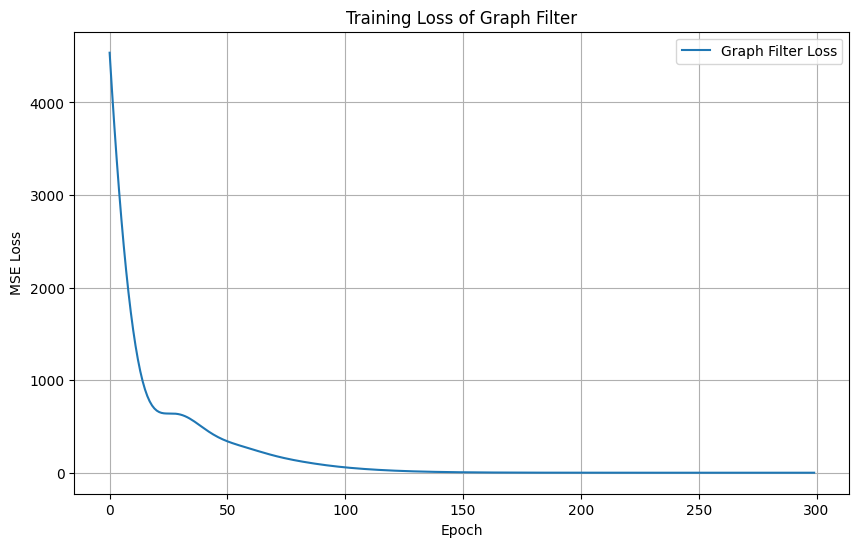

Training Graph Perceptron...
Epoch 10/300, Loss: 8064.350586
Epoch 20/300, Loss: 3490.082031
Epoch 30/300, Loss: 1152.497437
Epoch 40/300, Loss: 298.318390
Epoch 50/300, Loss: 77.715111
Epoch 60/300, Loss: 23.562120
Epoch 70/300, Loss: 9.525091
Epoch 80/300, Loss: 4.959691
Epoch 90/300, Loss: 3.093643
Epoch 100/300, Loss: 2.157223
Epoch 110/300, Loss: 1.609840
Epoch 120/300, Loss: 1.254439
Epoch 130/300, Loss: 1.008533
Epoch 140/300, Loss: 0.831660
Epoch 150/300, Loss: 0.700520
Epoch 160/300, Loss: 0.599896
Epoch 170/300, Loss: 0.519966
Epoch 180/300, Loss: 0.454696
Epoch 190/300, Loss: 0.400370
Epoch 200/300, Loss: 0.354610
Epoch 210/300, Loss: 0.315811
Epoch 220/300, Loss: 0.282772
Epoch 230/300, Loss: 0.254478
Epoch 240/300, Loss: 0.230092
Epoch 250/300, Loss: 0.208989
Epoch 260/300, Loss: 0.190666
Epoch 270/300, Loss: 0.174684
Epoch 280/300, Loss: 0.160663
Epoch 290/300, Loss: 0.148291
Epoch 300/300, Loss: 0.137331


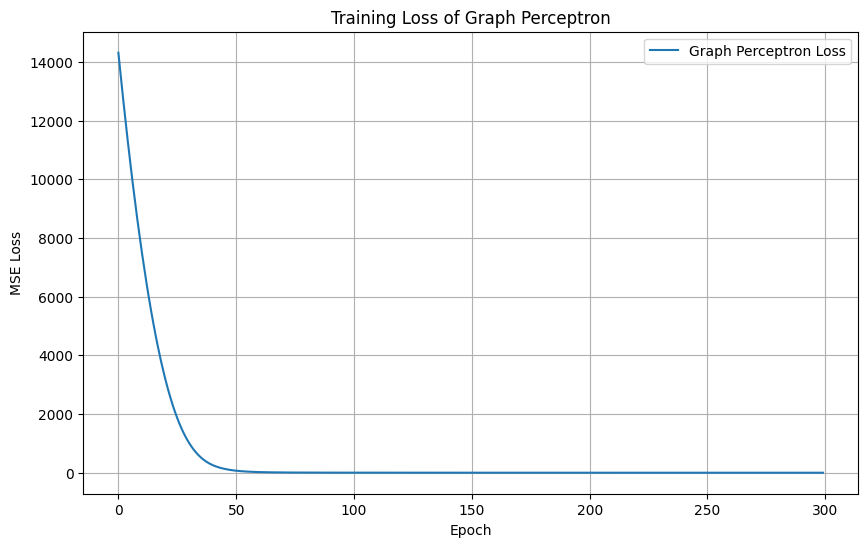

In [123]:
corr = stock_graph(y_train)
corr = normalize_graph(corr)
corr = torch.tensor(corr, dtype=torch.float32)

K = 3
gf_model = graph_filter(corr, K)
gp_model = graph_perceptron(corr, K, nn.ReLU())

print("Training Graph Filter...")
gf_model, gf_losses = train_model(gf_model, x_train_tensor, y_train_tensor)
# plot loss per epoch for graph filter
plt.figure(figsize=(10, 6))
plt.plot(gf_losses, label='Graph Filter Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Graph Filter')
plt.legend()
plt.grid()
plt.show()

print("Training Graph Perceptron...")
gp_model, gp_losses = train_model(gp_model, x_train_tensor, y_train_tensor)
# plot loss per epoch for graph perceptron
plt.figure(figsize=(10, 6))
plt.plot(gp_losses, label='Graph Perceptron Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Graph Perceptron')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# for multi features add: past 5 days data, moving average, volatility, etc.